In [1]:
import experiment_utils
from experiment_utils import config

config.experiment_name = "inHomo_realHelmholtz_dirichlet_1d_5pts"
config.target = "jmlr"
config.debug_mode = True

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import probnum as pn

import linpde_gp
from linpde_gp.problems.pde import get_1d_dirichlet_boundary_observations

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [3]:
%matplotlib inline

plt.rcParams.update(config.tueplots_bundle(rel_width=1.0))

class HelmholtzBeliefPlotter:
    def __init__(self, bvp: linpde_gp.problems.pde.HelmholtzEquationDirichletProblem):
        self._bvp = bvp
        self._plt_grid = np.linspace(*bvp.pde.domain, 100)

    def plot_belief(
        self,
        ax,
        u: pn.randprocs.GaussianProcess,
        conditioned_on: list[str] = [],
        X_pde: np.ndarray | None = None,
        f_X_pde: pn.randvars.RandomVariable | None = None,
    ):
        u_conditional_strs = []

        for key in conditioned_on:
            if key == "bc":
                u_conditional_strs.append(r"u\vert_{\partial \Omega} = g")
            elif key == "pde":
                u_conditional_strs.append(r"(\Delta + \kappa^2) u(x_i) = f(x_i)")

        u_label_base = (
            fr"$u \mid {', '.join(u_conditional_strs)}$"
            if len(u_conditional_strs) > 0
            else "$u$"
        )

        # Plot GP belief
        u.plot(
            ax,
            self._plt_grid,
            num_samples=10,
            rng=np.random.default_rng(24),
            color="C0",
            label=u_label_base,
        )

        # Plot true solution if available
        if self._bvp.solution is not None:
            sol_vals = self._bvp.solution(self._plt_grid)
            ax.plot(
                self._plt_grid,
                sol_vals,
                color="C1",
                label="$u^*$",
            )

        # Plot boundary conditions
        for key in conditioned_on:
            if key == "bc":
                X_bc, Y_bc = get_1d_dirichlet_boundary_observations(self._bvp.boundary_conditions)

                X_bc = np.atleast_1d(X_bc).flatten()

                if Y_bc.ndim == 2:
                    # Check if all columns have the same values (scalar problem)
                    if Y_bc.shape[1] > 1 and np.allclose(Y_bc[:, 0], Y_bc[:, 1]):
                        # All columns are the same, just use the first one
                        Y_bc = Y_bc[:, 0]
                    elif Y_bc.shape[1] == 1:
                        # Single column, just squeeze
                        Y_bc = Y_bc.squeeze(axis=1)
                    else:
                        # Different values in columns - use first column with warning
                        print(f"Warning: Y_bc has shape {Y_bc.shape} with different column values - using first column")
                        Y_bc = Y_bc[:, 0]
        
                Y_bc = np.atleast_1d(Y_bc).flatten()
                
                ax.scatter(
                    X_bc,
                    Y_bc,
                    marker="+",
                    color="C2",
                    label=r"$g$",
                )
                    
            elif key == "pde" and X_pde is not None:
                # Compute the derivatives for visualization
                du_dx = linpde_gp.linfuncops.diffops.PartialDerivative(
                    linpde_gp.linfuncops.diffops.MultiIndex(1)
                )(u)(X_pde).mean
                
                # For Helmholtz: ∇²u = f - k²u
                # So the second derivative contribution is (f - k²u)
                u_vals = u.mean(X_pde)
                ddu_contribution = f_X_pde - self._bvp.pde.k_squared * u_vals
                
                linpde_gp.utils.plotting.plot_local_curvature(
                    ax,
                    xs=X_pde,
                    f_xs=u_vals,
                    ddf_xs=ddu_contribution,
                    df_xs=du_dx,
                    color="C3",
                    label=r"$\{\text{local Taylor approximations of }u\}$",
                )

        # ax.legend(fontsize='small', loc='best')
        ax.legend()
        ax.set_xlabel("$x$")
        ax.set_ylabel("$u(x)$")

    def plot_pred_belief(
        self,
        ax,
        u: pn.randprocs.GaussianProcess,
        conditioned_on: list[str] = [],
        X_pde: np.ndarray | None = None,
        f_X_pde: pn.randvars.RandomVariable | None = None,
    ):
        u_conditional_strs = []

        for key in conditioned_on:
            if key == "bc":
                u_conditional_strs.append(r"u\vert_{\partial \Omega} = g")
            elif key == "pde":
                u_conditional_strs.append(r"(\Delta + \kappa^2) u(x_i) = f(x_i)")

        # Display k² value in the label
        k_squared_str = f"{self._bvp.pde.k_squared:.2f}"
        
        u_label_base = (
            fr"$(\Delta + {k_squared_str}) u \mid {', '.join(u_conditional_strs)}$"
            if len(u_conditional_strs) > 0
            else fr"$(\Delta + {k_squared_str}) u$"
        )

        # Apply the Helmholtz operator
        helmholtz_u = self._bvp.pde.diffop(u)
        
        helmholtz_u.plot(
            ax,
            self._plt_grid,
            num_samples=10,
            rng=np.random.default_rng(24),
            color="C0",
            label=u_label_base,
        )

        # Plot RHS
        self._bvp.pde.rhs.plot(
            ax,
            self._plt_grid,
            color="C1",
            label="$f$",
        )

        if "pde" in conditioned_on and X_pde is not None:
            ax.scatter(
                X_pde,
                f_X_pde,
                marker="+",
                c="C3",
                label=f"$(f(x_1), \dots, f(x_{X_pde.shape[0]}))$",
            )

        # ax.legend(fontsize='small', loc='best')
        ax.legend()
        ax.set_xlabel("$x$")
        ax.set_ylabel(fr"$(\Delta + {k_squared_str}) u(x)$")

## Problem Definition

In [4]:
domain = linpde_gp.domains.asdomain([-1.0, 1.0])

# Physical parameters
rho = 1.0
omega = 1.0
G_real = 1.0
G_imag = 0.0 # real-valued problem

In [5]:
# Boundary Values
g = (0.0, 0.0)
# g = np.asarray((1.0, 0.0))

# PDE RHS
f = linpde_gp.functions.Constant(input_shape=(), value=2.0)
# f = pn.functions.LambdaFunction(lambda x: np.pi ** 2 * np.sin(np.pi * x), input_shape=())

# True Solution
# solution = None
solution = pn.functions.LambdaFunction(lambda x: 2*(1 - np.cos(x)/np.cos(1)), input_shape=())

In [6]:
bvp_nonhomo = linpde_gp.problems.pde.HelmholtzEquationDirichletProblem(
    domain=domain,
    rho=rho,
    omega=omega,
    G_real=G_real,
    G_imag=G_imag,
    boundary_values=g,
    rhs=f,
    solution=solution
)

plotter_nonhomo = HelmholtzBeliefPlotter(bvp_nonhomo)

## Prior

In [7]:
# Prior GP for the Helmholtz problem
u_prior = pn.randprocs.GaussianProcess(
    mean=linpde_gp.functions.Zero(input_shape=()),
    cov=2.0 ** 2 * linpde_gp.randprocs.covfuncs.ExpQuad(
        input_shape=(),
        lengthscales=1.0,
    ),
)

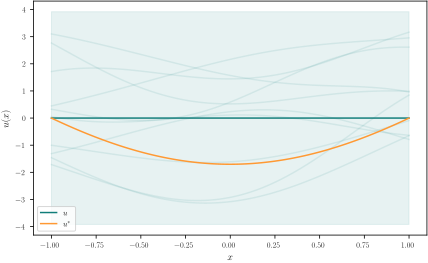

In [8]:
# Plot the prior belief
plotter_nonhomo.plot_belief(
    ax=plt.gca(),
    u=u_prior,
)

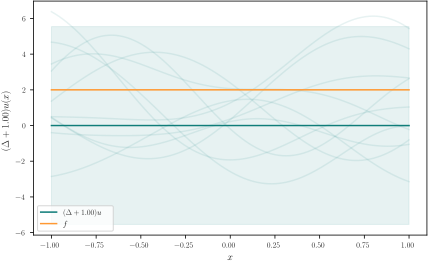

In [9]:
# Plot the prior predictive belief for the Helmholtz operator
plotter_nonhomo.plot_pred_belief(
    ax=plt.gca(),
    u=u_prior,
)

## Observations

In [10]:
# PDE observations
X_pde = domain.uniform_grid((5,), inset=0.1)
Y_pde = bvp_nonhomo.pde.rhs(X_pde)

In [11]:
X_bc = np.array([[-1.0], [1.0]]).reshape(-1,1)
Y_bc = np.array([0.0, 0.0]).reshape(-1,1)

## Posterior (PDE First)

### Conditioning on the PDE

In [12]:
u_cond_pde = u_prior.condition_on_observations(
    Y_pde,
    X=X_pde,
    L=bvp_nonhomo.pde.diffop,
)

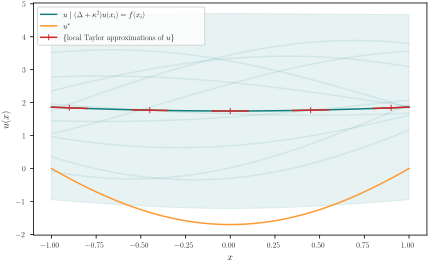

In [13]:
plotter_nonhomo.plot_belief(
    ax=plt.gca(),
    u=u_cond_pde,
    conditioned_on=["pde"],
    X_pde=X_pde,
    f_X_pde=Y_pde,
)

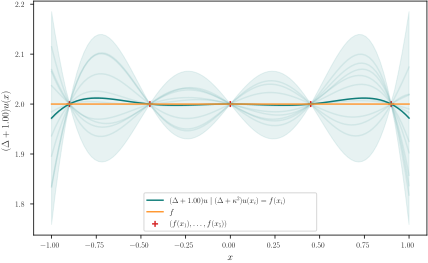

In [14]:
plotter_nonhomo.plot_pred_belief(
    ax=plt.gca(),
    u=u_cond_pde,
    conditioned_on=["pde"],
    X_pde=X_pde,
    f_X_pde=Y_pde,
)

# experiment_utils.savefig("pdefirst_01b_Du_cond_pde")

### Conditioning on the Boundary Conditions

In [15]:
u_cond_pde_bc = u_cond_pde.condition_on_observations(Y_bc, X=X_bc)

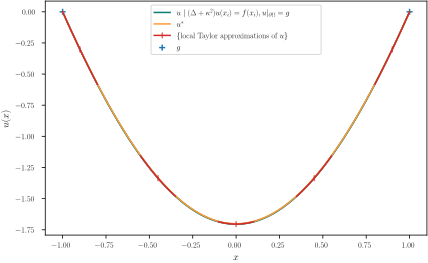

In [16]:
plotter_nonhomo.plot_belief(
    ax=plt.gca(),
    u=u_cond_pde_bc,
    conditioned_on=["pde", "bc"],
    X_pde=X_pde,
    f_X_pde=Y_pde,
)

# experiment_utils.savefig("pdefirst_02a_u_cond_pde_bc")

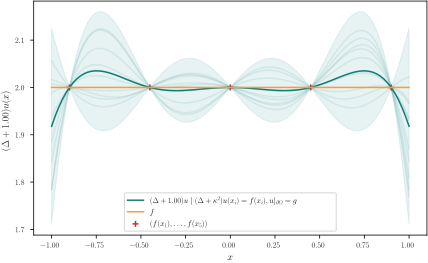

In [17]:
# Plot final predictive belief
plotter_nonhomo.plot_pred_belief(
    ax=plt.gca(),
    u=u_cond_pde_bc,
    conditioned_on=["pde", "bc"],
    X_pde=X_pde,
    f_X_pde=Y_pde,
)
# experiment_utils.savefig("pdefirst_02b_Du_cond_pde_bc")

## Posterior (Boundary Values First)

### Conditioning on Boundary Conditions

In [18]:
u_cond_bc = u_prior.condition_on_observations(Y_bc, X=X_bc)

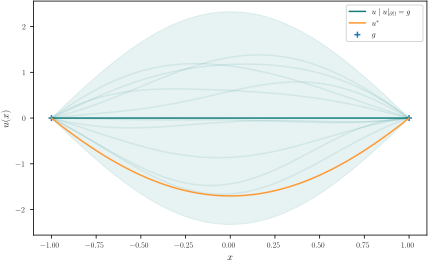

In [19]:
plotter_nonhomo.plot_belief(
    ax=plt.gca(),
    u=u_cond_bc,
    conditioned_on=["bc"],
)

experiment_utils.savefig("bcfirst_01a_u_cond_bc")

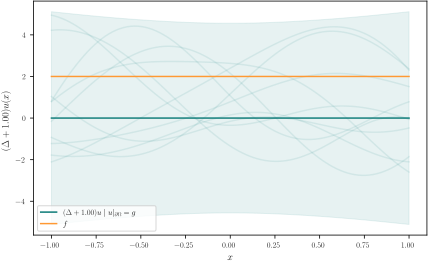

In [20]:
plotter_nonhomo.plot_pred_belief(
    ax=plt.gca(),
    u=u_cond_bc,
    conditioned_on=["bc"],
)

experiment_utils.savefig("bcfirst_01b_Du_cond_bc")

### Conditioning on the PDE

In [21]:
u_cond_bc_pde = u_cond_bc.condition_on_observations(
    Y=Y_pde,
    L=bvp_nonhomo.pde.diffop,
    X=X_pde,
)

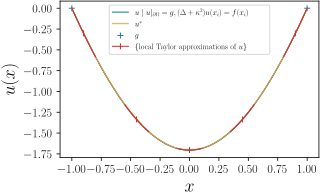

In [22]:
rc_composite = config.tueplots_bundle(nrows=3, ncols=2, rel_width=1.5)
figwidth = rc_composite.get('figure.figsize', [6.4, 4.8])[0]
figheight = rc_composite.get('figure.figsize', [6.4, 4.8])[1]

single_width = figwidth / 2  # 2 columns
single_height = figheight / 3  # 3 rows

rc = config.tueplots_bundle(nrows=1, ncols=1)
rc['figure.figsize'] = [single_width, single_height]
rc.update(
    {
        "lines.linewidth": 1,
        "font.size": 14,
        "axes.labelsize": 18,
        "legend.fontsize": 8,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.titlesize": 18,
    }
)
with plt.rc_context(rc):
    fig, ax = plt.subplots(nrows=1, ncols=1)
    plotter_nonhomo.plot_belief(
        ax=ax,
        u=u_cond_bc_pde,
        conditioned_on=["bc", "pde"],
        X_pde=X_pde,
        f_X_pde=Y_pde,
    )
    plt.savefig("solution_belief_bc_pde_5pts.pdf", bbox_inches='tight')

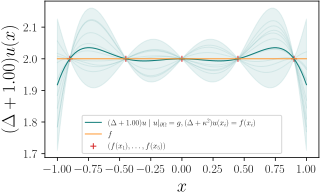

In [23]:
rc_composite = config.tueplots_bundle(nrows=3, ncols=2, rel_width=1.5)
figwidth = rc_composite.get('figure.figsize', [6.4, 4.8])[0]
figheight = rc_composite.get('figure.figsize', [6.4, 4.8])[1]
single_width = figwidth / 2  # 2 columns
single_height = figheight / 3  # 3 rows

rc = config.tueplots_bundle(nrows=1, ncols=1)
rc['figure.figsize'] = [single_width, single_height]
rc.update(
    {
        "lines.linewidth": 1,
        "font.size": 14,
        "axes.labelsize": 18,
        "legend.fontsize": 8,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.titlesize": 18,
    }
)
with plt.rc_context(rc):
    fig, ax = plt.subplots(nrows=1, ncols=1)
    plotter_nonhomo.plot_pred_belief(
        ax=ax,
        u=u_cond_bc_pde,
        conditioned_on=["bc", "pde"],
        X_pde=X_pde,
        f_X_pde=Y_pde,
    )
    plt.savefig("rhs_belief_bc_pde_5pts.pdf", bbox_inches='tight')

### Complete Plot

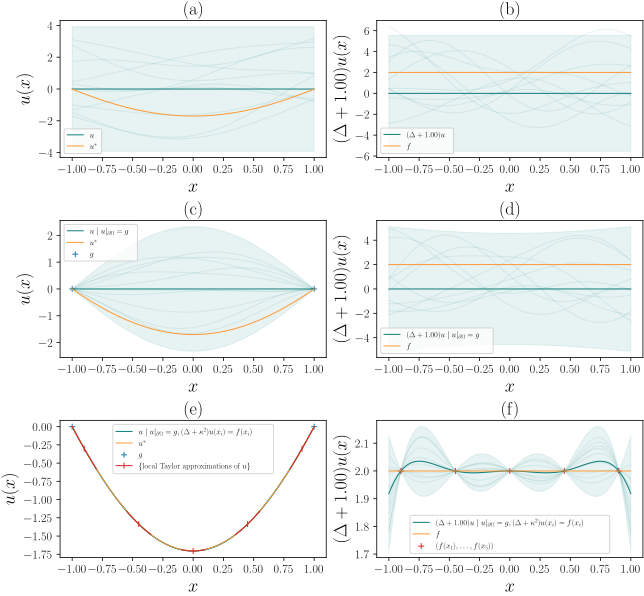

In [24]:
rc = config.tueplots_bundle(nrows=3, ncols=2, rel_width=1.5)
rc.update(
    {
        "lines.linewidth": 1,
        "font.size": 14,
        "axes.labelsize": 18,
        "legend.fontsize": 8,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.titlesize": 18,
    }
)

with plt.rc_context(rc):
    fig, ax = plt.subplots(nrows=3, ncols=2)

    ax[0, 0].set_title("(a)")

    plotter_nonhomo.plot_belief(
        ax=ax[0, 0],
        u=u_prior,
    )

    ax[0, 1].set_title("(b)")

    plotter_nonhomo.plot_pred_belief(
        ax=ax[0, 1],
        u=u_prior,
    )

    ax[1, 0].set_title("(c)")

    plotter_nonhomo.plot_belief(
        ax=ax[1, 0],
        u=u_cond_bc,
        conditioned_on=["bc"],
    )

    ax[1, 1].set_title("(d)")

    plotter_nonhomo.plot_pred_belief(
        ax=ax[1, 1],
        u=u_cond_bc,
        conditioned_on=["bc"],
    )

    ax[2, 0].set_title("(e)")

    plotter_nonhomo.plot_belief(
        ax=ax[2, 0],
        u=u_cond_bc_pde,
        conditioned_on=["bc", "pde"],
        X_pde=X_pde,
        f_X_pde=Y_pde,
    )

    ax[2, 1].set_title("(f)")

    plotter_nonhomo.plot_pred_belief(
        ax=ax[2, 1],
        u=u_cond_bc_pde,
        conditioned_on=["bc", "pde"],
        X_pde=X_pde,
        f_X_pde=Y_pde,
    )

#plt.savefig("inHomo_realHelmholtz_dirichlet_1d_5pts.pdf", bbox_inches='tight')

In [25]:
from typing import List, Dict, Optional

def compute_metrics(u_pred: np.ndarray, 
                   u_true: np.ndarray,
                   metrics: Optional[List[str]] = None) -> Dict[str, float]:
    """Compute evaluation metrics."""
    if metrics is None:
        metrics = ["mse", "rmse", "mae", "max_error", "relative_l2", "r2"]
    
    u_pred = np.atleast_1d(u_pred).flatten()
    u_true = np.atleast_1d(u_true).flatten()
    
    metric_functions = {
        "mse": lambda y_true, y_pred: np.mean((y_true - y_pred)**2),
        "rmse": lambda y_true, y_pred: np.sqrt(np.mean((y_true - y_pred)**2)),
        "mae": lambda y_true, y_pred: np.mean(np.abs(y_true - y_pred)),
        "max_error": lambda y_true, y_pred: np.max(np.abs(y_true - y_pred)),
        "r2": lambda y_true, y_pred: 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2),
        "relative_l2": lambda y_true, y_pred: np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true) if np.linalg.norm(y_true) > 0 else np.inf
    }
    
    results = {}
    for metric in metrics:
        if metric in metric_functions:
            results[metric] = metric_functions[metric](u_true, u_pred)
    
    return results

def analytical_solution(x: np.ndarray) -> np.ndarray:
    """The analytical solution for Helmholtz problem."""
    x = np.atleast_1d(x).flatten()
    return 2.0 * (1.0 - np.cos(x) / np.cos(1.0))

In [26]:
x_test = np.linspace(-1.0, 1.0, 1000)
u_pred = u_cond_bc_pde.mean(x_test.reshape(-1, 1)).flatten()
u_true = analytical_solution(x_test)

# Compute metrics
metrics = compute_metrics(u_pred, u_true)

# Print results
print("=" * 50)
print("EVALUATION METRICS".center(50))
print("=" * 50)
print(f"  R² Score:            {metrics['r2']:12.6f}")
print(f"  MSE:                 {metrics['mse']:12.6e}")
print(f"  Mean Absolute Error: {metrics['mae']:12.6e}")
print(f"  Maximum Error:       {metrics['max_error']:12.6e}")
print(f"  Relative L2 Error:   {metrics['relative_l2']:12.6e}")
print("=" * 50)

                EVALUATION METRICS                
  R² Score:                0.999978
  MSE:                 5.830424e-06
  Mean Absolute Error: 2.290833e-03
  Maximum Error:       2.769884e-03
  Relative L2 Error:   1.968202e-03
